# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_df = pd.read_csv('./data/tweet_sentiment_train.csv')
raw_df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [5]:
print('\nКількість пропущених значень по колонках:')
print(raw_df.isnull().sum())


Кількість пропущених значень по колонках:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


In [6]:
# Видалення рядків з пропущеними значеннями
raw_df = raw_df.dropna().reset_index(drop=True)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [8]:
# Аналіз розподілу класів
sentiment_distribution = (
    raw_df['sentiment']
    .value_counts()
    .to_frame(name='count')
)

sentiment_distribution['percent'] = (
    raw_df['sentiment']
    .value_counts(normalize=True)
    .round(3) * 100
)

sentiment_distribution

,count,percent
sentiment,,
neutral,11117,40.5
positive,8582,31.2
negative,7781,28.3


In [9]:
# Статистика довжин текстів
raw_df['text_length'] = raw_df['text'].str.len()

print('Статистика довжин текстів:')
print(raw_df['text_length'].describe().round(1))

Статистика довжин текстів:
count    27480.0
mean        68.3
std         35.6
min          3.0
25%         39.0
50%         64.0
75%         97.0
max        141.0
Name: text_length, dtype: float64


In [10]:
# Статистика довжин текстів для кожного sentiment
raw_df['text_length'] = raw_df['text'].str.len()

text_length_stats_by_sentiment = (
    raw_df
    .groupby('sentiment')['text_length']
    .describe()
    .round(1)
)

text_length_stats_by_sentiment

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,7781.0,70.5,35.2,5.0,42.0,66.0,98.0,141.0
neutral,11117.0,65.2,36.4,3.0,35.0,59.0,94.0,141.0
positive,8582.0,70.4,34.6,5.0,42.0,67.0,98.0,138.0


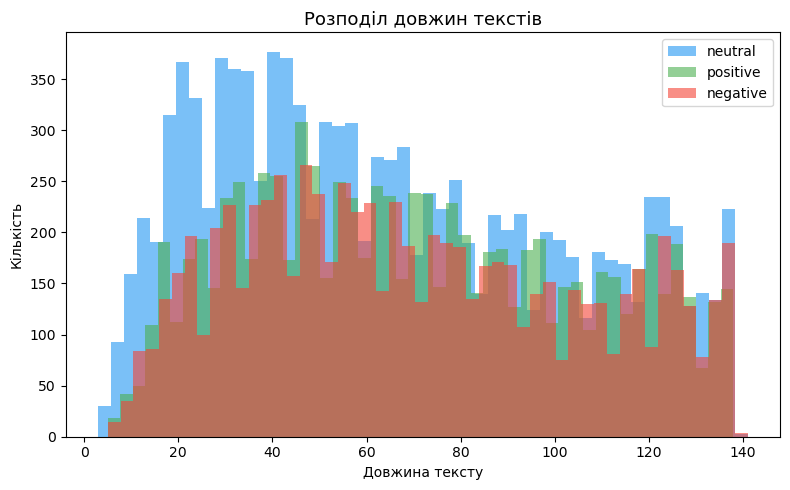

In [11]:
plt.figure(figsize=(8, 5))

# Гістограма довжин текстів по класах сентименту
for sentiment, color in zip(
    ['neutral', 'positive', 'negative'], 
    ['#2196F3', '#4CAF50', '#F44336']
):
    subset = raw_df[raw_df['sentiment'] == sentiment]['text_length']
    plt.hist(
        subset, 
        bins=50, 
        alpha=0.6, 
        label=sentiment, 
        color=color
    )

plt.title('Розподіл довжин текстів', fontsize=13)
plt.xlabel('Довжина тексту')
plt.ylabel('Кількість')
plt.legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

Суттєвої різниці між класами за довжиною тексту не спостерігається. 
Тому ознака text_length, ймовірно, не буде дуже сильною для прогнозування sentiment, але її можна залишити як додаткову допоміжну ознаку.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [14]:
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/aroslavbuhanovskij/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
# Стеммер
stemmer = SnowballStemmer('english')

# Список стоп-слів
stop_words = stopwords.words('english')

def preprocess_text(text):
    """
    Повна попередня обробка тексту:
    1. Приведення до нижнього регістру
    2. Видалення URL-посилань
    3. Видалення згадок (@username) та хештегів (#tag символ)
    4. Видалення спеціальних символів та цифр
    5. Токенізація по словах (regex)
    6. Видалення стоп-слів
    7. Стемінг
    """
    # 1. Нижній регістр
    text = text.lower()
    # 2. Видалення URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Видалення @mentions та # символу
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    # 4. Зірочки → токен CENSORED
    text = re.sub(r'\*+', ' censored ', text)
    # 5. Видалення спецсимволів (крім апострофа) та цифр
    text = re.sub(r"[^a-z'\s]", '', text)
    # 6. Токенізація
    tokens = text.split()
    # 7. Видалення стоп-слів та коротких токенів
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    # 8. Стемінг
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

# Приклад
example = raw_df['text'].iloc[5]
print('Оригінал:', example)
print('Після обробки:', preprocess_text(example))

Оригінал: http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth
Після обробки: shameless plug best ranger forum earth


In [16]:
# Застосування попередньої обробки до всього датасету
raw_df['text_processed'] = raw_df['text'].apply(preprocess_text)
raw_df[['text', 'text_processed']].head(10)

,text,text_processed
0,"I`d have responded, if I were going",id respond go
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad miss san diego
2,my boss is bullying me...,boss bulli
3,what interview! leave me alone,interview leav alon
4,"Sons of ****, why couldn`t they put them on t...",son censor couldnt put releas alreadi bought
5,http://www.dothebouncy.com/smf - some shameles...,shameless plug best ranger forum earth
6,2am feedings for the baby are fun when he is a...,feed babi fun smile coo
7,Soooo high,soooo high
8,Both of you,
9,Journey!? Wow... u just became cooler. hehe....,journey wow becam cooler hehe possibl


In [17]:
# Аналіз словника для вибору max_features
# Підрахуємо кількість унікальних токенів
from collections import Counter

all_tokens = ' '.join(raw_df['text_processed']).split()
token_counts = Counter(all_tokens)
print(f'Загальна кількість унікальних токенів: {len(token_counts)}')
print(f'Токенів, що зустрічаються хоча б 3 рази: {sum(1 for c in token_counts.values() if c >= 3)}')
print(f'Токенів, що зустрічаються хоча б 5 разів: {sum(1 for c in token_counts.values() if c >= 5)}')
print(f'\nНайчастіші 20 токенів:')
print(token_counts.most_common(20))

Загальна кількість унікальних токенів: 21510
Токенів, що зустрічаються хоча б 3 рази: 5581
Токенів, що зустрічаються хоча б 5 разів: 3699

Найчастіші 20 токенів:
[('im', 3056), ('day', 2416), ('go', 2363), ('get', 1909), ('censor', 1684), ('good', 1569), ('work', 1483), ('love', 1458), ('like', 1454), ('dont', 1202), ('today', 1115), ('got', 1087), ('time', 1079), ('one', 1055), ('cant', 1030), ('happi', 993), ('want', 983), ('know', 969), ('thank', 963), ('miss', 961)]


In [18]:
# Вибираємо max_features=5600 — охоплює більшість значущих слів
MAX_FEATURES = 5600

# Bag of Words векторизація
bow_vectorizer = CountVectorizer(
    max_features=MAX_FEATURES,
    min_df=3        # ігноруємо токени, що зустрічаються менше 3 разів
)

X_bow = bow_vectorizer.fit_transform(raw_df['text_processed'])
print('Форма матриці BoW:', X_bow.shape)
print('Кількість ознак у словнику:', len(bow_vectorizer.get_feature_names_out()))

Форма матриці BoW: (27480, 5493)
Кількість ознак у словнику: 5493


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [21]:
# Розбивка на train/test за індексами (щоб потім використовувати ті самі для TF-IDF)
y = raw_df['sentiment']

train_idx, test_idx = train_test_split(
    raw_df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_bow = X_bow[train_idx]
X_test_bow  = X_bow[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

print(f'Train: {X_train_bow.shape[0]} рядків')
print(f'Test:  {X_test_bow.shape[0]} рядків')

Train: 21984 рядків
Test:  5496 рядків


In [22]:
# Порівняємо кілька моделей
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='sag', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_test_bow)
    predict_proba = model.predict_proba(X_test_bow)[:, 1]
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results[name] = {'accuracy': acc, 'f1': f1, 'model': model, 'preds': preds, 'predict_proba': predict_proba}
    print(f'{name}: Accuracy={acc:.4f}, F1={f1:.4f}')

Logistic Regression: Accuracy=0.6878, F1=0.6885
Decision Tree: Accuracy=0.6228, F1=0.6071


In [23]:
# Обираємо найкращу модель — Logistic Regression
best_model_bow = results['Logistic Regression']['model']

# Статистика на тренувальних та тестових даних
train_preds = best_model_bow.predict(X_train_bow)
test_preds  = best_model_bow.predict(X_test_bow)

print('=== TRAIN ===')
print(classification_report(y_train, train_preds))

print('=== TEST ===')
print(classification_report(y_test, test_preds))

# Зведена таблиця
summary = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Accuracy': [
        round(accuracy_score(y_train, train_preds), 4),
        round(accuracy_score(y_test,  test_preds),  4)
    ],
    'F1': [
        round(f1_score(y_train, train_preds, average='weighted'), 4),
        round(f1_score(y_test,  test_preds,  average='weighted'), 4)
    ]
})
print(summary.to_string(index=False))

=== TRAIN ===
              precision    recall  f1-score   support

    negative       0.85      0.77      0.81      6225
     neutral       0.78      0.86      0.82      8894
    positive       0.87      0.83      0.85      6865

    accuracy                           0.82     21984
   macro avg       0.83      0.82      0.82     21984
weighted avg       0.83      0.82      0.82     21984

=== TEST ===
              precision    recall  f1-score   support

    negative       0.70      0.64      0.67      1556
     neutral       0.63      0.71      0.67      2223
    positive       0.77      0.70      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496

Split  Accuracy     F1
Train    0.8228 0.8229
 Test    0.6878 0.6885


Accuracy на train значно вища ніж на test, а отже модель перенавчилась. Сам результат вийшов помірним і потребує подальшого вдосконалення

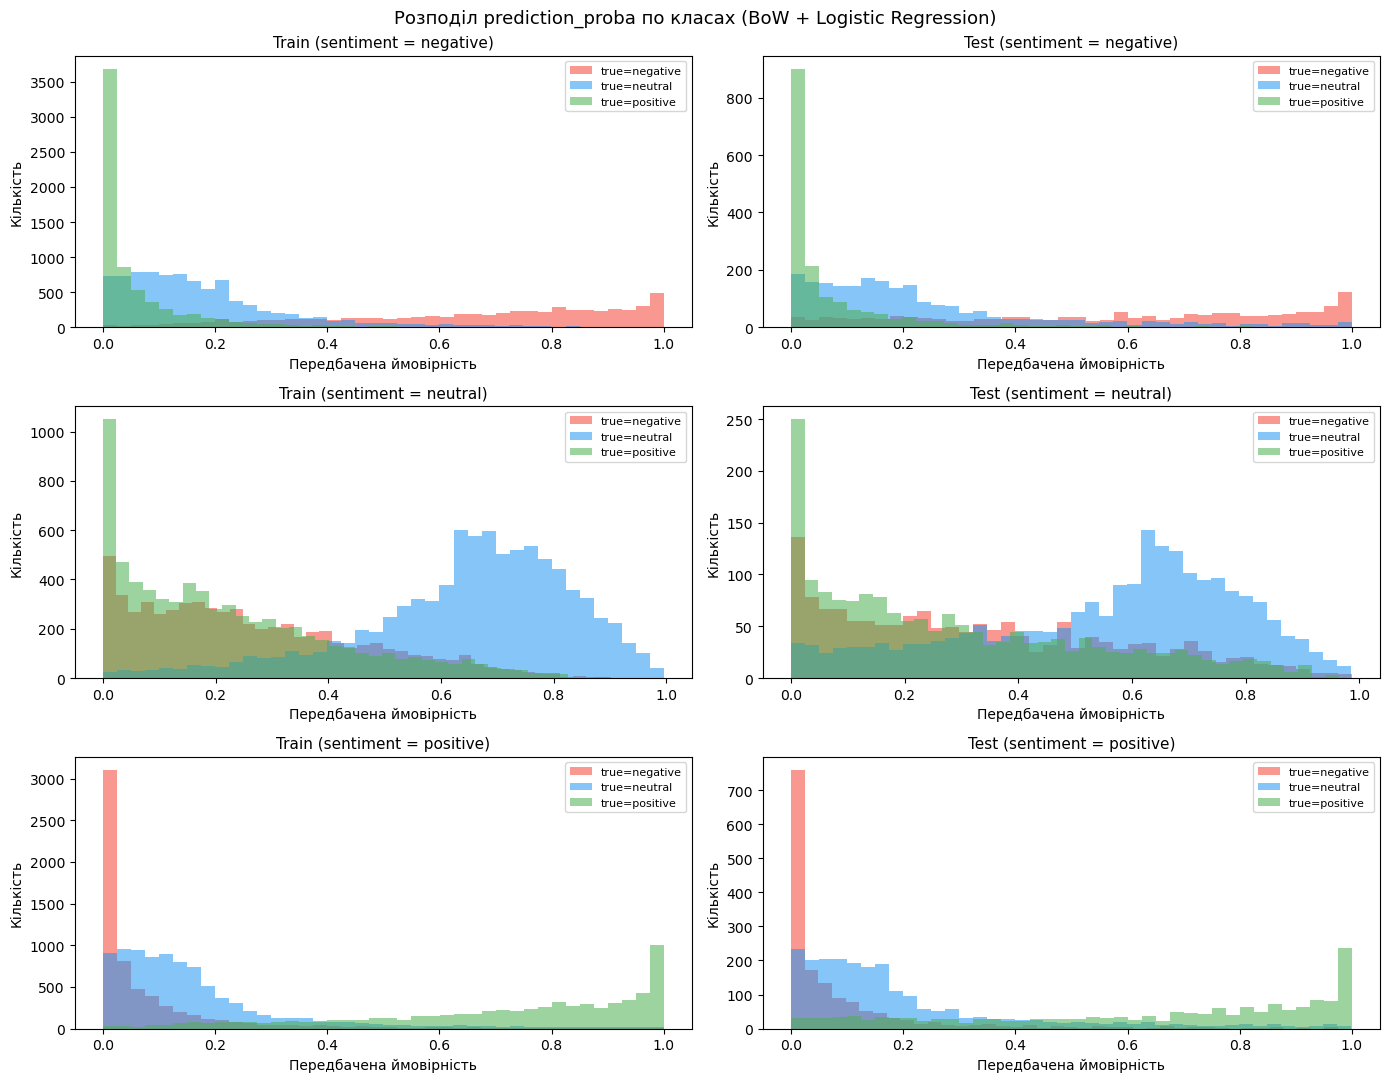

In [25]:
# Гістограми prediction_proba для кожного класу сентименту

proba_train = best_model_bow.predict_proba(X_train_bow)
proba_test  = best_model_bow.predict_proba(X_test_bow)
classes     = best_model_bow.classes_
colors      = {'negative': '#F44336', 'neutral': '#2196F3', 'positive': '#4CAF50'}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))

for col_i, (X_proba, y_labels, split_name) in enumerate([
    (proba_train, y_train, 'Train'),
    (proba_test,  y_test,  'Test')
]):
    for row_i, cls in enumerate(classes):
        cls_idx = list(classes).index(cls)
        ax = axes[row_i][col_i]
        for true_cls in classes:
            mask = (y_labels == true_cls).values
            probas = X_proba[mask, cls_idx]
            ax.hist(probas, bins=40, alpha=0.55, label=f'true={true_cls}', color=colors[true_cls])
        ax.set_title(f'{split_name} (sentiment = {cls})', fontsize=11)
        ax.set_xlabel('Передбачена ймовірність')
        ax.set_ylabel('Кількість')
        ax.legend(fontsize=8)

plt.suptitle('Розподіл prediction_proba по класах (BoW + Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.show()

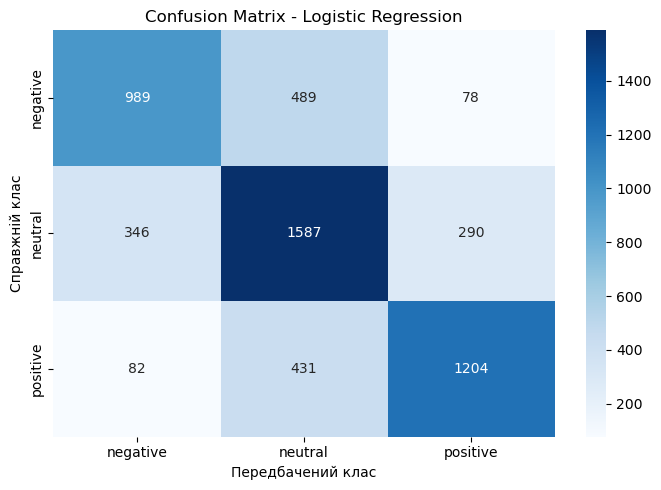

In [26]:
# Матриця помилок
cm = confusion_matrix(y_test, test_preds, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.tight_layout()
plt.savefig('cm_bow.png', dpi=100)
plt.show()

Отже Logistic Regression показала кращий результат за Decision Tree.

Модель показує дуже гарну класифікацію позитивного контексту, нейтральний і негативний натомість відрізняється складніше.

Якість помірна і потребує подальшого вдосконалення

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


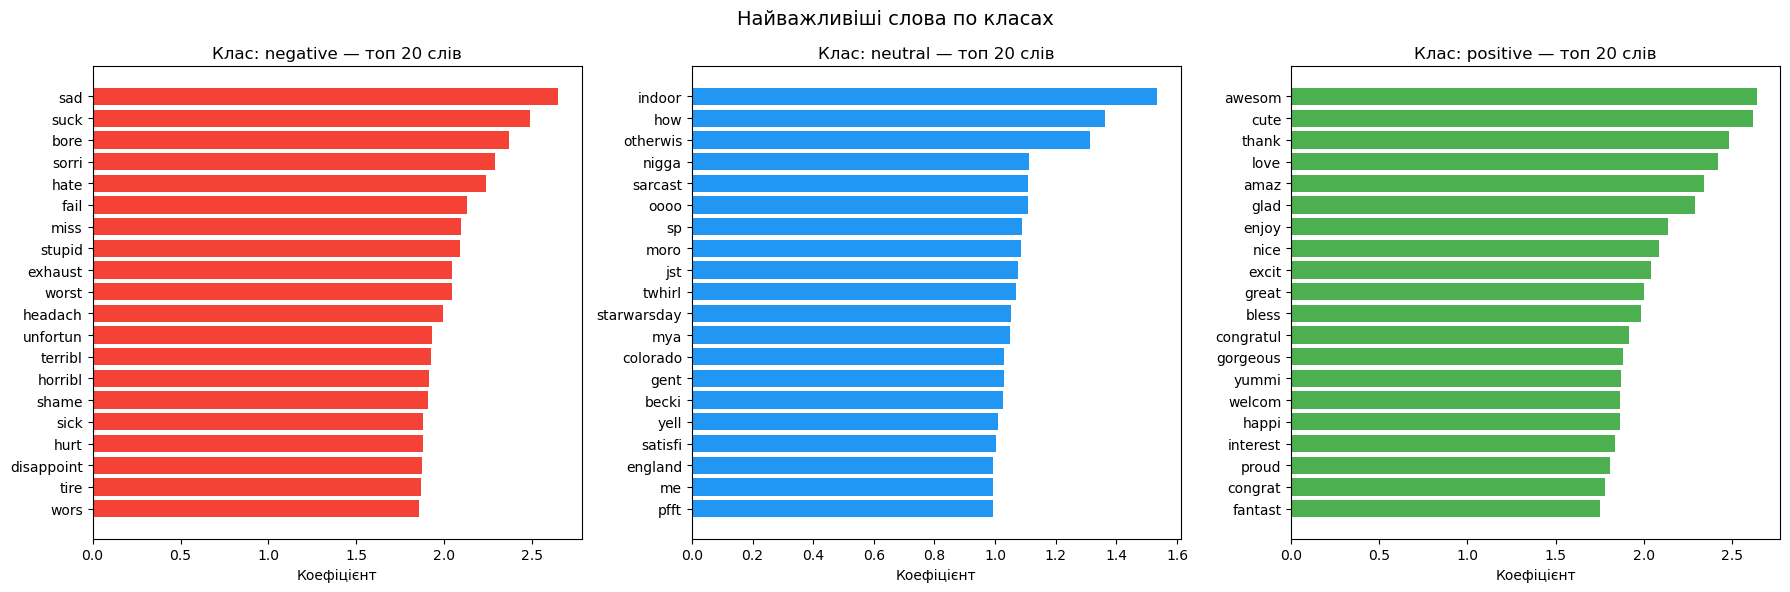

In [29]:
feature_names = bow_vectorizer.get_feature_names_out()
classes = best_model_bow.classes_
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'negative': '#F44336', 'neutral': '#2196F3', 'positive': '#4CAF50'}

for i, cls in enumerate(classes):
    coefs = best_model_bow.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]
    top_words = feature_names[top_idx]
    top_vals = coefs[top_idx]
    
    axes[i].barh(top_words[::-1], top_vals[::-1], color=colors[cls])
    axes[i].set_title(f'Клас: {cls} — топ {TOP_N} слів', fontsize=12)
    axes[i].set_xlabel('Коефіцієнт')

plt.suptitle('Найважливіші слова по класах', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance_bow.png', dpi=100)
plt.show()

Результат цілком логічний, адже модель відображає конкретні індикатори емоцій. Єдине, що б я проаналізував більш детально - попадання слова 'nigga' в нейтральний клас

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [33]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=3
)

X_tfidf = tfidf_vectorizer.fit_transform(raw_df['text_processed'])
print('Форма матриці TF-IDF:', X_tfidf.shape)

Форма матриці TF-IDF: (27480, 5493)


In [34]:
# Використовуємо ТІ САМІ індекси train/test що і для BoW!
X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf  = X_tfidf[test_idx]

# Та сама модель — Logistic Regression
lr_tfidf = LogisticRegression(max_iter=1000, solver='saga', random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
# Статистика на тренувальних та тестових даних
train_tfidf_preds = lr_tfidf.predict(X_train_tfidf)
test_tfidf_preds  = lr_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, test_tfidf_preds)
f1_tfidf  = f1_score(y_test, test_tfidf_preds, average='weighted')

print(f'TF-IDF — Accuracy: {acc_tfidf:.4f}, F1: {f1_tfidf:.4f}')

print('=== TRAIN ===')
print(classification_report(y_train, train_tfidf_preds))

print('=== TEST ===')
print(classification_report(y_test, test_tfidf_preds))

# Зведена таблиця
summary = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'Accuracy': [
        round(accuracy_score(y_train, train_tfidf_preds), 4),
        round(accuracy_score(y_test,  test_tfidf_preds),  4)
    ],
    'F1': [
        round(f1_score(y_train, train_tfidf_preds, average='weighted'), 4),
        round(f1_score(y_test,  test_tfidf_preds,  average='weighted'), 4)
    ]
})
print(summary.to_string(index=False))

TF-IDF — Accuracy: 0.6889, F1: 0.6894
=== TRAIN ===
              precision    recall  f1-score   support

    negative       0.82      0.71      0.76      6225
     neutral       0.72      0.84      0.77      8894
    positive       0.84      0.77      0.81      6865

    accuracy                           0.78     21984
   macro avg       0.79      0.77      0.78     21984
weighted avg       0.79      0.78      0.78     21984

=== TEST ===
              precision    recall  f1-score   support

    negative       0.72      0.61      0.66      1556
     neutral       0.62      0.75      0.68      2223
    positive       0.78      0.68      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496

Split  Accuracy     F1
Train    0.7802 0.7803
 Test    0.6889 0.6894


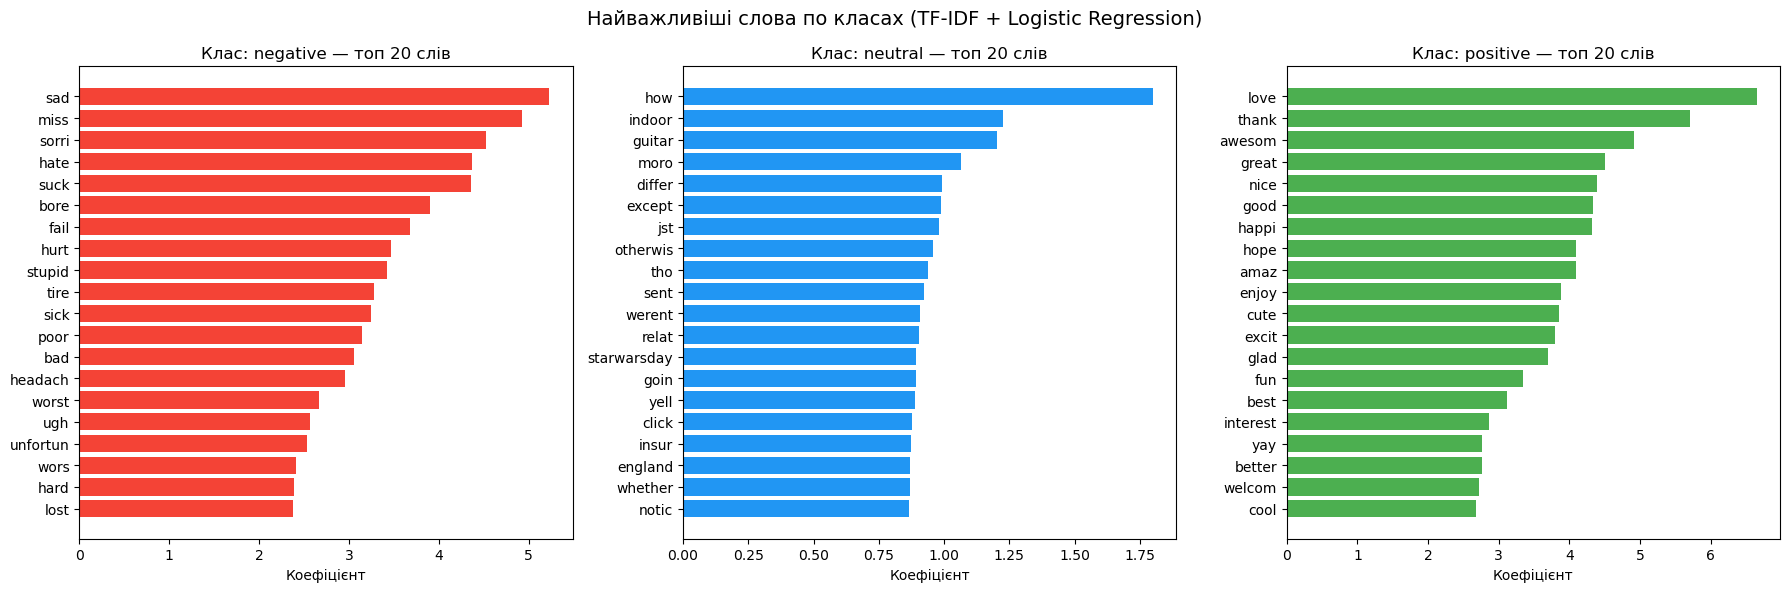

In [36]:
# Важливі слова для TF-IDF
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
classes_tfidf = lr_tfidf.classes_

for i, cls in enumerate(classes_tfidf):
    coefs = lr_tfidf.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]
    top_words = tfidf_feature_names[top_idx]
    top_vals = coefs[top_idx]
    
    axes[i].barh(top_words[::-1], top_vals[::-1], color=colors[cls])
    axes[i].set_title(f'Клас: {cls} — топ {TOP_N} слів', fontsize=12)
    axes[i].set_xlabel('Коефіцієнт')

plt.suptitle('Найважливіші слова по класах (TF-IDF + Logistic Regression)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance_tfidf.png', dpi=100)
plt.show()

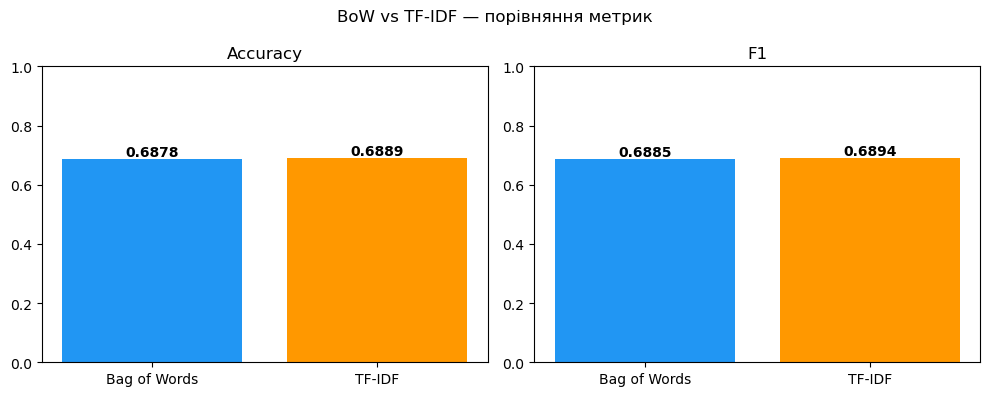

In [37]:
# Порівняння BoW vs TF-IDF
acc_bow = results['Logistic Regression']['accuracy']
f1_bow  = results['Logistic Regression']['f1']

comparison = pd.DataFrame({
    'Метод': ['Bag of Words', 'TF-IDF'],
    'Accuracy': [acc_bow, acc_tfidf],
    'F1': [f1_bow, f1_tfidf]
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['Accuracy', 'F1']):
    ax.bar(comparison['Метод'], comparison[metric], color=['#2196F3', '#FF9800'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.suptitle('BoW vs TF-IDF — порівняння метрик')
plt.tight_layout()
plt.savefig('bow_vs_tfidf.png', dpi=100)
plt.show()

Отже, векторизація TF-IDF показує незначно кращий результат класифікації на тестових даних, але різниця показників з тренувальними даними тут значно менша, порівняно з BoW, що свідчить про менший рівень оверфіту. Саме тому я вважаю кращим використовувати для прогнозу векторизацію TF-IDF

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

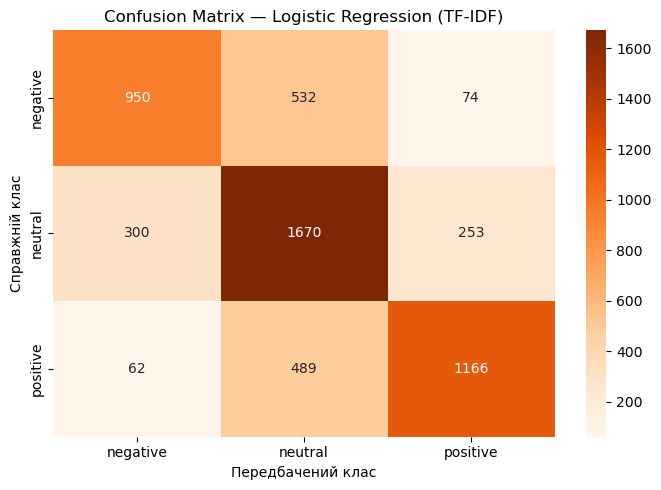

In [75]:
# Матриця помилок для TF-IDF
cm_tfidf = confusion_matrix(y_test, test_tfidf_preds, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix — Logistic Regression (TF-IDF)')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.tight_layout()
plt.savefig('cm_tfidf.png', dpi=100)
plt.show()

Отже, по кількості найбільше помилок серед негативного класу та позитивного класу, які були передбачені як нейтрапльні. Проаналізуємо це детальніше

In [97]:
test_df = raw_df.loc[test_idx].copy()
test_df['prediction'] = test_tfidf_preds

In [113]:
# Приклади помилок
print('Приклади: TRUE=negative, PREDICTED=positive')
mask = (test_df['sentiment'] == 'negative') & (test_df['prediction'] == 'positive')
print(test_df[mask][['text', 'sentiment']].head(10).to_string())

print('\nПриклади: TRUE=positive, PREDICTED=negative')
mask2 = (test_df['sentiment'] == 'positive') & (test_df['prediction'] == 'negative')
print(test_df[mask2][['text', 'sentiment']].head(10).to_string())

Приклади: TRUE=negative, PREDICTED=positive
                                                                                                                                        text sentiment
17483                                                                                                      Awww, *hugs* I wish I could help.  negative
27219                                                                            I can`t believe you tweeted that. It was our special moment  negative
8542                                  not ideal bank holiday conditions.. a little over cast and rainy but perfect for a lazy day with a dvd  negative
8916                                          _Happy_EmoX lmao. Lucky! It`s 10 minutes on foot for me  ewww..... School.lol. On the bus now.  negative
22556                                                     I wish I could just go for a drive..or a movie or the store..I just wanna be alone  negative
18834                                             

Отже, щодо методів покращення я б спробував наступні варіанти:
1. Перевірити чи зміщення порогу класифікації буде мати позитивний ефект
2. Перевірити як працюють на даних алгоритми бустингу
3. Зробити підбір гіперпараметрів

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model